   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


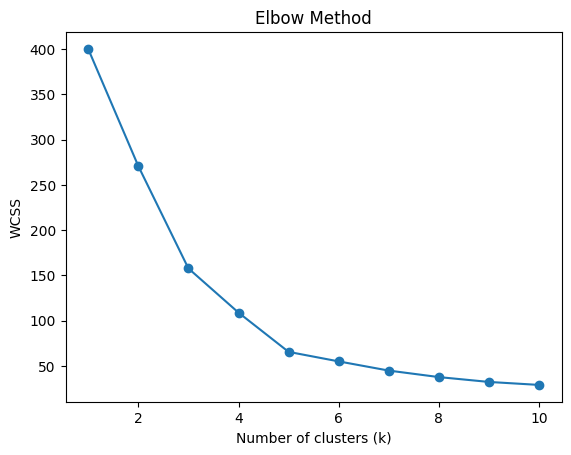

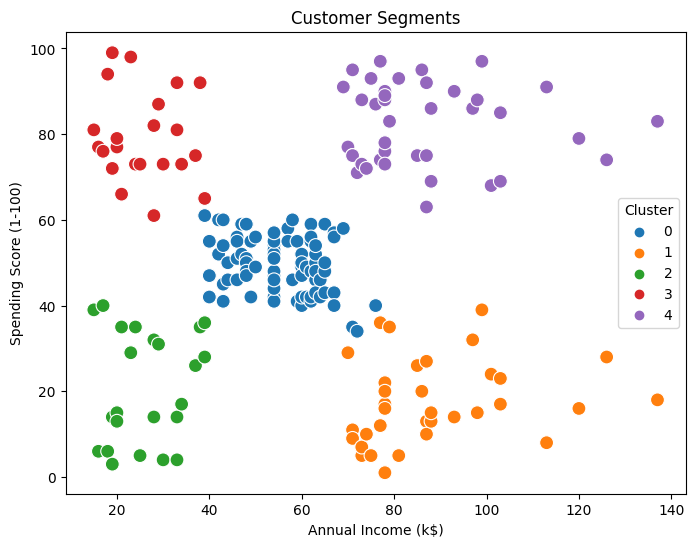

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 88.200000               17.114286
2                 26.304348               20.913043
3                 25.727273               79.363636
4                 86.538462               82.128205


In [2]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load dataset
# (On Kaggle you can just add the dataset to your notebook environment)
df = pd.read_csv("/kaggle/input/mall-dataset/Mall_Customers.csv")

# Quick look
print(df.head())
print(df.info())

# Step 3: Select features for clustering
# We'll use Annual Income and Spending Score
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Step 4: Scale the data (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Use Elbow Method to find best K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()

# Step 6: Fit KMeans with optimal clusters (say k=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Step 7: Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"],
                hue=df["Cluster"], palette="tab10", s=100)
plt.title("Customer Segments")
plt.show()


In [3]:
# Step 8: Look at cluster characteristics
cluster_means = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()
print("\n📌 Cluster Characteristics (Mean values):")
print(cluster_means)

# Step 9: Save clustered data to CSV so you can download from Kaggle
output_path = "/kaggle/working/customer_segments.csv"
df.to_csv(output_path, index=False)
print(f"\n💾 Clustered dataset saved as: {output_path}")


📌 Cluster Characteristics (Mean values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 88.200000               17.114286
2                 26.304348               20.913043
3                 25.727273               79.363636
4                 86.538462               82.128205

💾 Clustered dataset saved as: /kaggle/working/customer_segments.csv
